In [1]:
import pandas as pd

In [2]:
train = pd.read_csv('https://raw.githubusercontent.com/niteen11/data301_predictive_analytics_machine_learning/main/data/titanic_train.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
train.shape

(889, 10)

# EDA

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

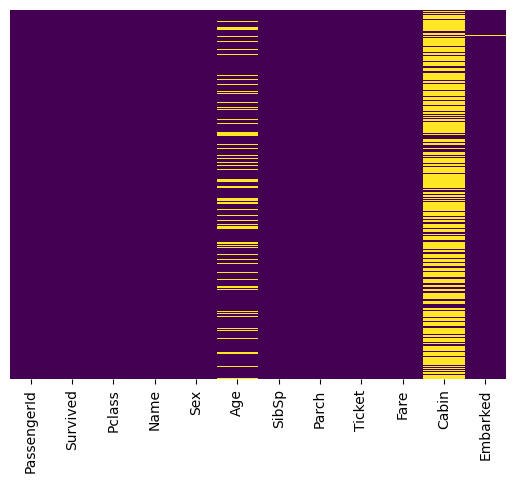

In [5]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [6]:
# Check the number of missing values in each column
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

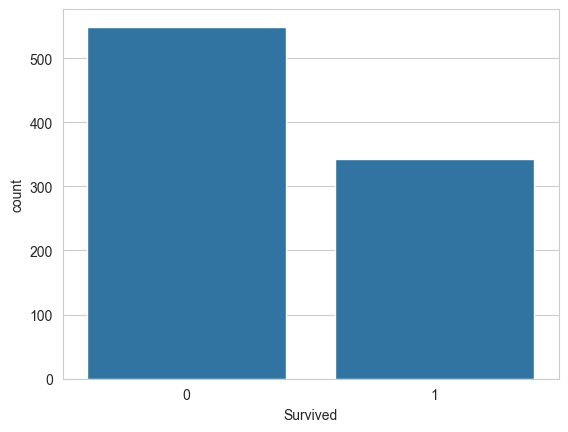

In [7]:
#class
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train)

<Axes: xlabel='Survived', ylabel='count'>

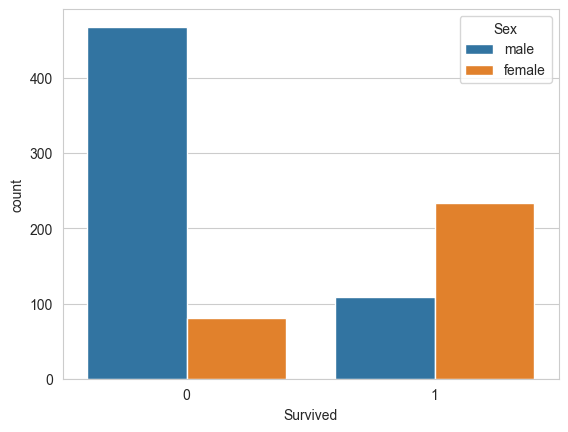

In [8]:
#survived
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train)

<Axes: xlabel='Survived', ylabel='count'>

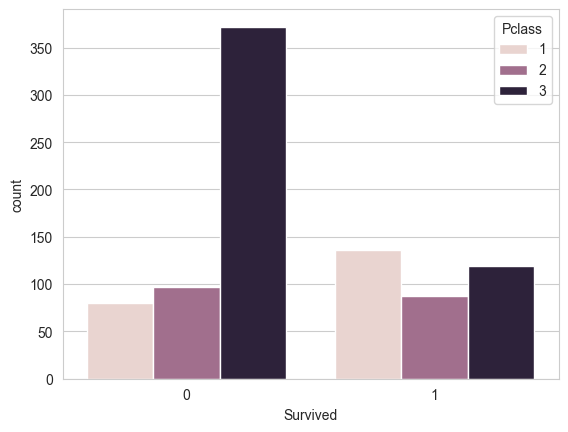

In [9]:
#survived
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train)

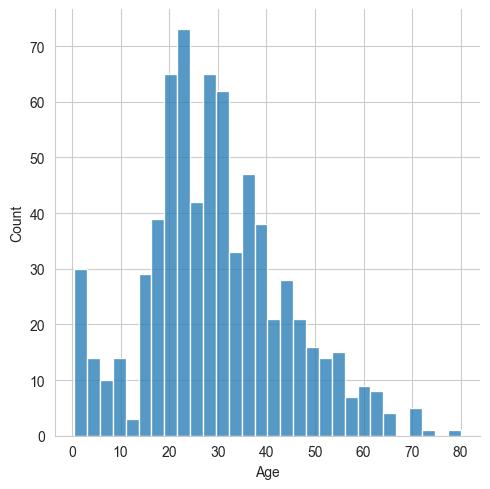

In [10]:
#age
sns.displot(train['Age'].dropna(), kde=False, bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

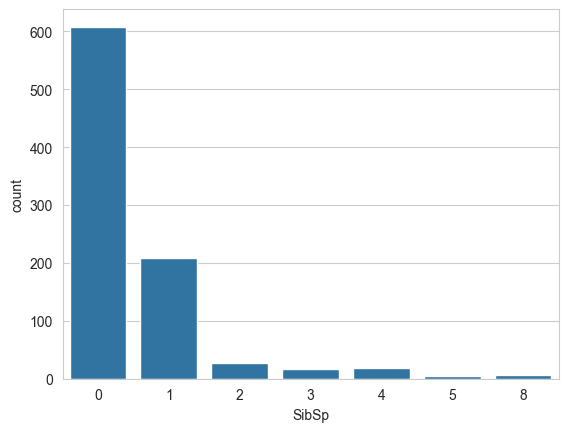

In [11]:
#siblings
sns.countplot(x='SibSp',data=train)

# Data Cleaning & Feature Engineering
In this section, we prepare the titanic data for machine learning by handling missing values, encoding categorical variables, removing unnecessary features, and creating a clean dataset that can be used to train the Logistic Regression model.

In [12]:
# Two equivalent ways:

train.drop("Cabin", axis=1, inplace=True) 

# train = train.drop(columns = ["cabin"])

# The Cabin column is removed because it contains a large number of missing values. 
# Instead of deleting hundreds of passenger records, it is more practical to remove the feature since 
# it is unlikely to provide enough useful information for this model.
# The Cabin feature has significantly more missing values than the other columns, making it difficult to use without extensive imputation.

In [13]:
# imputation function 

def impute_age(row):
    age = row["Age"]
    pclass = row["Pclass"]

    if pd.isnull(age):
        if pclass == 1:
            return 37
        elif pclass == 2:
            return 29
        else:
            return 24
    else:
        return age

Improvement: Instead of removing all passengers with missing Age values, I impute the missing ages using the passenger's class. This preserves more training data while providing a more informed estimate than simply dropping the rows.

In [14]:
train["Age"] = train[["Age", "Pclass"]].apply(impute_age, axis=1)

#This function fills missing Age values using the passenger's class. First-class passengers with missing ages are assigned 37, 
# second-class passengers 29, and third-class passengers 24.
#  apply(..., axis=1) applies the function to one passenger row at a time using both Age and Pclass.

In [15]:
#Checks the number of missing values remaining after dropping Cabin and imputing Age. 
# This confirms whether the cleaning step worked before continuing to encode categorical variables.
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [16]:
train.dropna(inplace=True)
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
# One-hot encode the categorical features Sex and Embarked into numerical columns 
# so they can be used by the Logistic Regression model. 
# drop_first=True removes one category from each feature to avoid redundant information (multicollinearity).
# so for sex youre gonna get a col for female, male then you remove the female 
# for embark you get three coloms for c, q, s and u remove the c , 00 meaning c 

sex = pd.get_dummies(train['Sex'], drop_first=True, dtype=int)
embark = pd.get_dummies(train['Embarked'], drop_first=True, dtype=int)

In [ ]:
#Remove the original categorical columns after creating their encoded versions. 
# Name and Ticket are also removed 
# because they are unlikely to improve the model and are difficult to use directly for prediction.

train.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace= True)

train.head()
# train = train.drop(columns = ['Sex','Embarked','Name','Ticket'])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [ ]:
#Append the encoded Sex and Embarked columns to the dataset. 
# The dataset now contains only numerical features that can be used for model training.

train = pd.concat([train, sex, embark],axis=1)
train.head()

#train["male"]= sex["male"]
#train["Q"]= embark["Q"]
#train["S"]= embark["S"]

#train = train.join([sex, embark])



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


# MODEL BUILDING
✅ Explored the data (EDA)
✅ Cleaned the data
✅ Engineered features (imputed Age, encoded categories)
✅ Removed unusable columns
 ##### Now Train the MODEL

In [ ]:
#Import the function that splits our dataset into training and testing sets.
#The training set is used to train the model,
#  while the testing set is used to evaluate how well the model performs on unseen data.

from sklearn.model_selection import train_test_split

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     train.drop("Survived", axis=1),
#     train["Survived"],
#     test_size=0.3,
#     random_state=101
# )

X = train.drop("Survived", axis=1)

y = train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101
)

# Here's my features (X) and here's my target (y). Split both into training and testing sets.
# for test_size=.3 suppose we have 1000 rows of data 
# x_train y train will have 700 
# and x_test and y_test will  300 
#the train data gets 700 and the test gets 300
# Split both into training (70%) and testing (30%) sets.
#randome_state is to ensure the shuffling is conistent,Every time you run the notebook,you get the same train/test split. 
# ensure split is reusuable

In [24]:
from sklearn.linear_model import LogisticRegression

#Import the algorithm we want to use.
# Linear Regression → predicts numbers
# Logistic Regression → predicts classes (0 or 1)

In [ ]:
logmodel = LogisticRegression()

#Build me an empty Logistic Regression model.
#Create an empty Logistic Regression model. 
# At this stage, the model has not learned from the data yet; it is simply initialized and ready for training.

In [ ]:
# Train the Logistic Regression model using the training data.
# The model analyzes the relationship between the input features (X_train) and the target labels (y_train) 
# to learn patterns that can later be used to predict survival for new passengers.

logmodel.fit(X_train, y_train)

#The algorithm studies:

# Features (X_train)
# ↓

# Target (y_train)

# ↓

# Learns relationships

# ↓

# Creates a mathematical model

# Fit a model to the data.
# We're telling sklearn
# "Here are the passenger features."
# Age
# Pclass
# Fare
# male
# Q
# S
# ...
# and
# "Here are the correct answers."
# Survived
# 0
# 1
# 1
# 0
# 1
# ...
# Now the algorithm tries to discover the relationship. learns Probability of Surviving.. learns coeficients like 
# As age increases, predicted survival probability tends to decrease slightly. -.03 etc

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [27]:
logmodel.classes_

array([0, 1])

In [ ]:
prob=logmodel.predict_proba(X_test)
prob[:5]


array([[0.86308794, 0.13691206],
       [0.90344387, 0.09655613],
       [0.18958709, 0.81041291],
       [0.10867938, 0.89132062],
       [0.89729783, 0.10270217]])

In [ ]:
predict = logmodel.predict(X_test)
# Logistic Regression actually predicts probabilities:
# 0.82
# 0.17
# 0.63
# 0.91

# Then .predict() converts them into
# 1
# 0
# 1
# 1
# using a default threshold of 0.5.
# Then predict() simply chooses the class with the higher probability
predict[:5]

array([0, 0, 1, 1, 0])

In [ ]:
results = pd.DataFrame(
prob, 
columns=["P(Not Survived)", "P(Survived)"]
)

results["Prediction"] = predict
results["Actual"] = y_test.values

results.head()

,P(Not Survived),P(Survived),Prediction,Actual
0,0.863088,0.136912,0,0
1,0.903444,0.096556,0,0
2,0.189587,0.810413,1,1
3,0.108679,0.891321,1,1
4,0.897298,0.102702,0,0


In [39]:
compare = pd.DataFrame({
    "predicted" : predict,
    "actual": y_test
    }
    )
compare.head()

,predicted,actual
511,0,0
613,0,0
615,1,1
337,1,1
718,0,0


# Classification report

In [42]:
#Import the classification_report function from scikit-learn. 
# This function summarizes the model's classification performance 
# using precision, recall, F1-score, accuracy, and support for each class

from sklearn.metrics import classification_report

print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       163
           1       0.81      0.62      0.71       104

    accuracy                           0.80       267
   macro avg       0.80      0.77      0.78       267
weighted avg       0.80      0.80      0.79       267



The Logistic Regression model achieved 80% accuracy on the test set. It performed better at identifying passengers who did not survive (91% recall) than passengers who survived (62% recall). When the model predicted a passenger survived, it was correct 81% of the time (precision), but it missed a noticeable portion of actual survivors, resulting in a lower recall.

In [43]:
# Confusion Matrix

                    Predicted
                0             1

Actual 0      148            15
           (True Neg)   (False Pos)

Actual 1       39            65
          (False Neg)  (True Pos)

In [44]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predict)

array([[148,  15],
       [ 39,  65]])

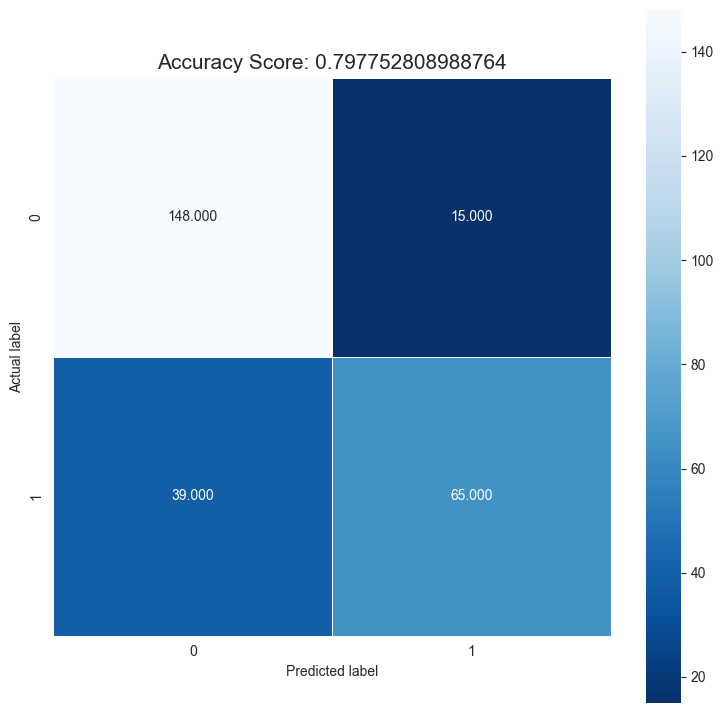

In [47]:
plt.figure(figsize=(9,9))
sns.heatmap(confusion_matrix(y_test, predict), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(logmodel.score(X_test, y_test))
plt.title(all_sample_title, size = 15);

 # ROC curve and AUC

 How does the model perform if we try every possible threshold?

 Receiver Operating Characteristic - It shows model performance across all classification thresholds.

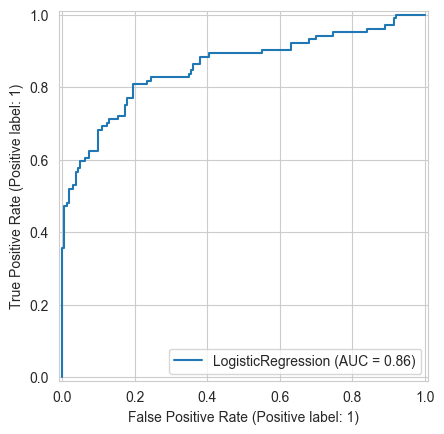

In [49]:
from sklearn.metrics import  RocCurveDisplay

RocCurveDisplay.from_estimator(logmodel, X_test, y_test)

ROC Curve / AUC: Evaluates how well the logistic regression model distinguishes between passengers who survived and did not survive across different classification thresholds. The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate. An AUC of approximately 0.86 indicates that the model has good ability to distinguish between the two classes.

# CONCLUSION

The Logistic Regression model achieved 80% accuracy and an ROC-AUC of 0.86. The model performed better at identifying passengers who did not survive (91% recall) than passengers who survived (62% recall). For passengers predicted to survive, the model had 81% precision. Overall, the model performed well, but it missed a noticeable portion of passengers who actually survived.